In [2]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from generalized_contrastive_PCA import gcPCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

### Channel labels

In [3]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [4]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [5]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [6]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

### Select bursts corresponding to C3/C4 and all STN contacts

In [7]:
c_idx = (all_bursts['channel']=='C3') | (all_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in all_bursts['channel']]

### Plot the beta burst waveform for sensorimotor cortex (C3,C4) Vs STN 

In [8]:
burst_times = all_bursts['waveform_times'] * 1000 

In [9]:
on_idx = (all_bursts['med']=='ON')
off_idx = (all_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [10]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

In [11]:
where = c_idx

# Scale waveforms within subject such as (X - median)/IQR 
scaled_waveforms = np.zeros_like(all_bursts['waveform'])

for subject in np.unique(all_bursts['subject']):
    subj_idx = (all_bursts['subject'] == subject)
    # scaler = RobustScaler().fit(all_bursts['waveform'][subj_idx])                       # .fit() returns the median and IQR values
    # scaler = StandardScaler().fit(all_bursts['waveform'][subj_idx])                     # .fit() returns the mean and std values
    # scaled_waveforms[subj_idx, :] = scaler.transform(all_bursts['waveform'][subj_idx])  # .transform() does the maths.
    
    median, mad = scaler_fit(all_bursts['waveform'][subj_idx & where])
    scaled_waveforms[subj_idx, :] = scaler_transform(all_bursts['waveform'][subj_idx], median, mad)

In [12]:
# Subject-level cross-validation: split subjects into train/test groups

n_splits = 10           # Number of folds for cross-validation
n_bins = 4              # Number of bins to use for each gcPC
cols = [0, 1, -2, -1]   # List of gcPC columns to consider

subjects_score = []
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject) & where
    trials = np.unique(all_bursts['trial'][subj_idx])

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)
    
    fold_score = []
    for fold_idx, (train_index, test_index) in enumerate(kf.split(trials)):
        train_bursts_idx = np.isin(all_bursts['trial'], trials[train_index]) & subj_idx
        train_bursts_on_idx = train_bursts_idx & (all_bursts['med']=='ON')
        train_bursts_off_idx = train_bursts_idx & (all_bursts['med']=='OFF')
            
        # GCPCA model trained only on test set bursts of the current subject
        gcpca_model = gcPCA(method='v4', normalize_flag=False)                                                      # gcPCA model creation
        gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])        # gcPCA application on OFF/ON cortex
        
        # Project all bursts of the current subject into PC space using the trained model
        all_scores = scaled_waveforms@gcpca_model.loadings_
        
        X = []
        y = []
        pc_bin_lims = np.zeros((len(cols), n_bins + 1))
        # Build trial-level feature matrix X and matching label vector y
        for trial in trials:
            # For each trial, count how many bursts fall into each bin for the current gcPC
            burst_idx = subj_idx & (all_bursts["trial"]==trial)
            label = np.unique(all_bursts["med"][burst_idx])[0]

            row = []
            for i, col in enumerate(cols):
                # Compute percentile edges for each gcPC of interest across all bursts 
                pc_bin_lims[i, :] = np.percentile(all_scores[train_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

                for idx in range(len(pc_bin_lims[i, :]) - 1):
                    # Count bursts whose gcPC score falls within the current percentile bin
                    count = len(np.where((all_scores[burst_idx, cols[i]] >= pc_bin_lims[i, idx]) &
                                        (all_scores[burst_idx, cols[i]] < pc_bin_lims[i, idx+1]))[0])
                    row.append(count)

            X.append(row)
            y.append(0 if label=='OFF' else 1)

        X = np.array(X)
        y = np.array(y)

        model = LOR()
        model = model.fit(X[train_index, :], y[train_index])
        y_pred = model.predict(X[test_index, :])

        score = 1 - np.sqrt(np.mean((y[test_index] - y_pred) ** 2))
        print(f'Subject {subject} fold {fold_idx}: Score = {score:.3f}')
        fold_score.append(score)

    print(f'Subject {subject}: Mean Score = {np.mean(fold_score):.3f} ± {np.std(fold_score):.3f}')
    subjects_score.append(np.mean(fold_score))

print(f'Overall Mean Score across subjects: {np.mean(subjects_score):.3f} ± {np.std(subjects_score):.3f}')

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 0: Score = 0.500
Subject s02 fold 1: Score = 0.500


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 2: Score = 0.134
Subject s02 fold 3: Score = 0.500


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


...

Subject s18 fold 5: Score = 1.000
Subject s18 fold 6: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 7: Score = 1.000
Subject s18 fold 8: Score = 1.000


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 9: Score = 1.000
Subject s18: Mean Score = 1.000 ± 0.000
Overall Mean Score across subjects: 0.708 ± 0.256


In [57]:
# Subject-level cross-validation: split subjects into train/test groups and save scores for different number of bins
# and subject-level model coefficients 

n_splits = 10  # Number of folds for cross-validation
n_bins = 4  # Number of bins to use for each gcPC
cols = [0, 1, -2, -1]  # List of gcPC columns to consider

subjects_coefs = {subject: [] for subject in subjects}  # Dictionary to store coefficients for each subject
subjects_bursts = {subject: [] for subject in subjects}  # Dictionary to store bursts and labels for each subject
subjects_score = []
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject) & where
    trials = np.unique(all_bursts['trial'][subj_idx])

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)
    
    coef = []
    fold_score = []
    for fold_idx, (train_index, test_index) in enumerate(kf.split(trials)):
        train_bursts_idx = np.isin(all_bursts['trial'], trials[train_index]) & subj_idx
        train_bursts_on_idx = train_bursts_idx & (all_bursts['med']=='ON')
        train_bursts_off_idx = train_bursts_idx & (all_bursts['med']=='OFF')
            
        # GCPCA model trained only on test set bursts of the current subject
        gcpca_model = gcPCA(method='v4', normalize_flag=False)                                # gcPCA model creation
        gcpca_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])        # gcPCA application on OFF/ON cortex
    
        # Project all bursts of the current subject into PC space using the trained model
        all_scores = scaled_waveforms@gcpca_model.loadings_
        
        X = []
        y = []
        pc_bin_lims = np.zeros((len(cols), n_bins + 1))

        # Build trial-level feature matrix X and matching label vector y
        for trial in trials:
            # For each trial, count how many bursts fall into each bin for the current gcPC
            burst_idx = subj_idx & (all_bursts["trial"]==trial)
            label = np.unique(all_bursts["med"][burst_idx])[0]

            row = []
            for i, col in enumerate(cols):
                # Compute percentile edges for each gcPC of interest across all bursts 
                pc_bin_lims[i, :] = np.percentile(all_scores[train_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

                for idx in range(len(pc_bin_lims[i, :]) - 1):
                    # Count bursts whose gcPC score falls within the current percentile bin
                    count = len(np.where((all_scores[burst_idx, cols[i]] >= pc_bin_lims[i, idx]) &
                                        (all_scores[burst_idx, cols[i]] < pc_bin_lims[i, idx+1]))[0])
                    row.append(count)

            X.append(row)
            y.append(0 if label=='OFF' else 1)

        X = np.array(X)
        y = np.array(y)

        subjects_bursts[subject].append(np.mean(X, axis=0))

        model = LOR(max_iter=1000)
        model = model.fit(X[train_index, :], y[train_index])
        y_train_pred = model.predict(X[train_index, :])
        y_test_pred = model.predict(X[test_index, :])
        coefs = model.coef_
        coef.append(coefs)

        train_score = 1 - np.sqrt(np.mean((y[train_index] - y_train_pred) ** 2))
        test_score = 1 - np.sqrt(np.mean((y[test_index] - y_test_pred) ** 2))
        print(f'Subject {subject} fold {fold_idx}: Train Score = {train_score:.3f}, Test Score = {test_score:.3f}, Min = {np.min(y[train_index])}, Max = {np.max(y[train_index])}')
        fold_score.append(test_score)

    print(f'Subject {subject}: Mean Score = {np.mean(fold_score):.3f} ± {np.std(fold_score):.3f}')
    subjects_score.append(np.mean(fold_score))
    subjects_coefs[subject].append(np.mean(coef, axis=0))


print(f'Overall Mean Score across subjects: {np.mean(subjects_score):.3f} ± {np.std(subjects_score):.3f}')

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 0: Train Score = 0.829, Test Score = 0.500, Min = 0, Max = 1
Subject s02 fold 1: Train Score = 1.000, Test Score = 0.500, Min = 0, Max = 1


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s02 fold 2: Train Score = 1.000, Test Score = 0.134, Min = 0, Max = 1
Subject s02 fold 3: Train Score = 1.000, Test Score = 0.500, Min = 0, Max = 1


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


...

c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 6: Train Score = 1.000, Test Score = 1.000, Min = 0, Max = 1
Subject s18 fold 7: Train Score = 1.000, Test Score = 1.000, Min = 0, Max = 1


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +
c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


Subject s18 fold 8: Train Score = 1.000, Test Score = 1.000, Min = 0, Max = 1
Subject s18 fold 9: Train Score = 1.000, Test Score = 1.000, Min = 0, Max = 1
Subject s18: Mean Score = 1.000 ± 0.000
Overall Mean Score across subjects: 0.708 ± 0.256


c:\Users\Loquet Jeremie\Documents\Python_Project\gcPCA\.venv\Lib\site-packages\generalized_contrastive_PCA\contrastive_methods.py:176: UserWarning: Denominator is ill-conditioned, fixing it. Be aware that gcPCA values will beslightly smaller
  warnings.warn('Denominator is ill-conditioned, fixing it. ' +


C:\Users\Loquet Jeremie\AppData\Local\Temp\ipykernel_15540\3147607232.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(subjects))


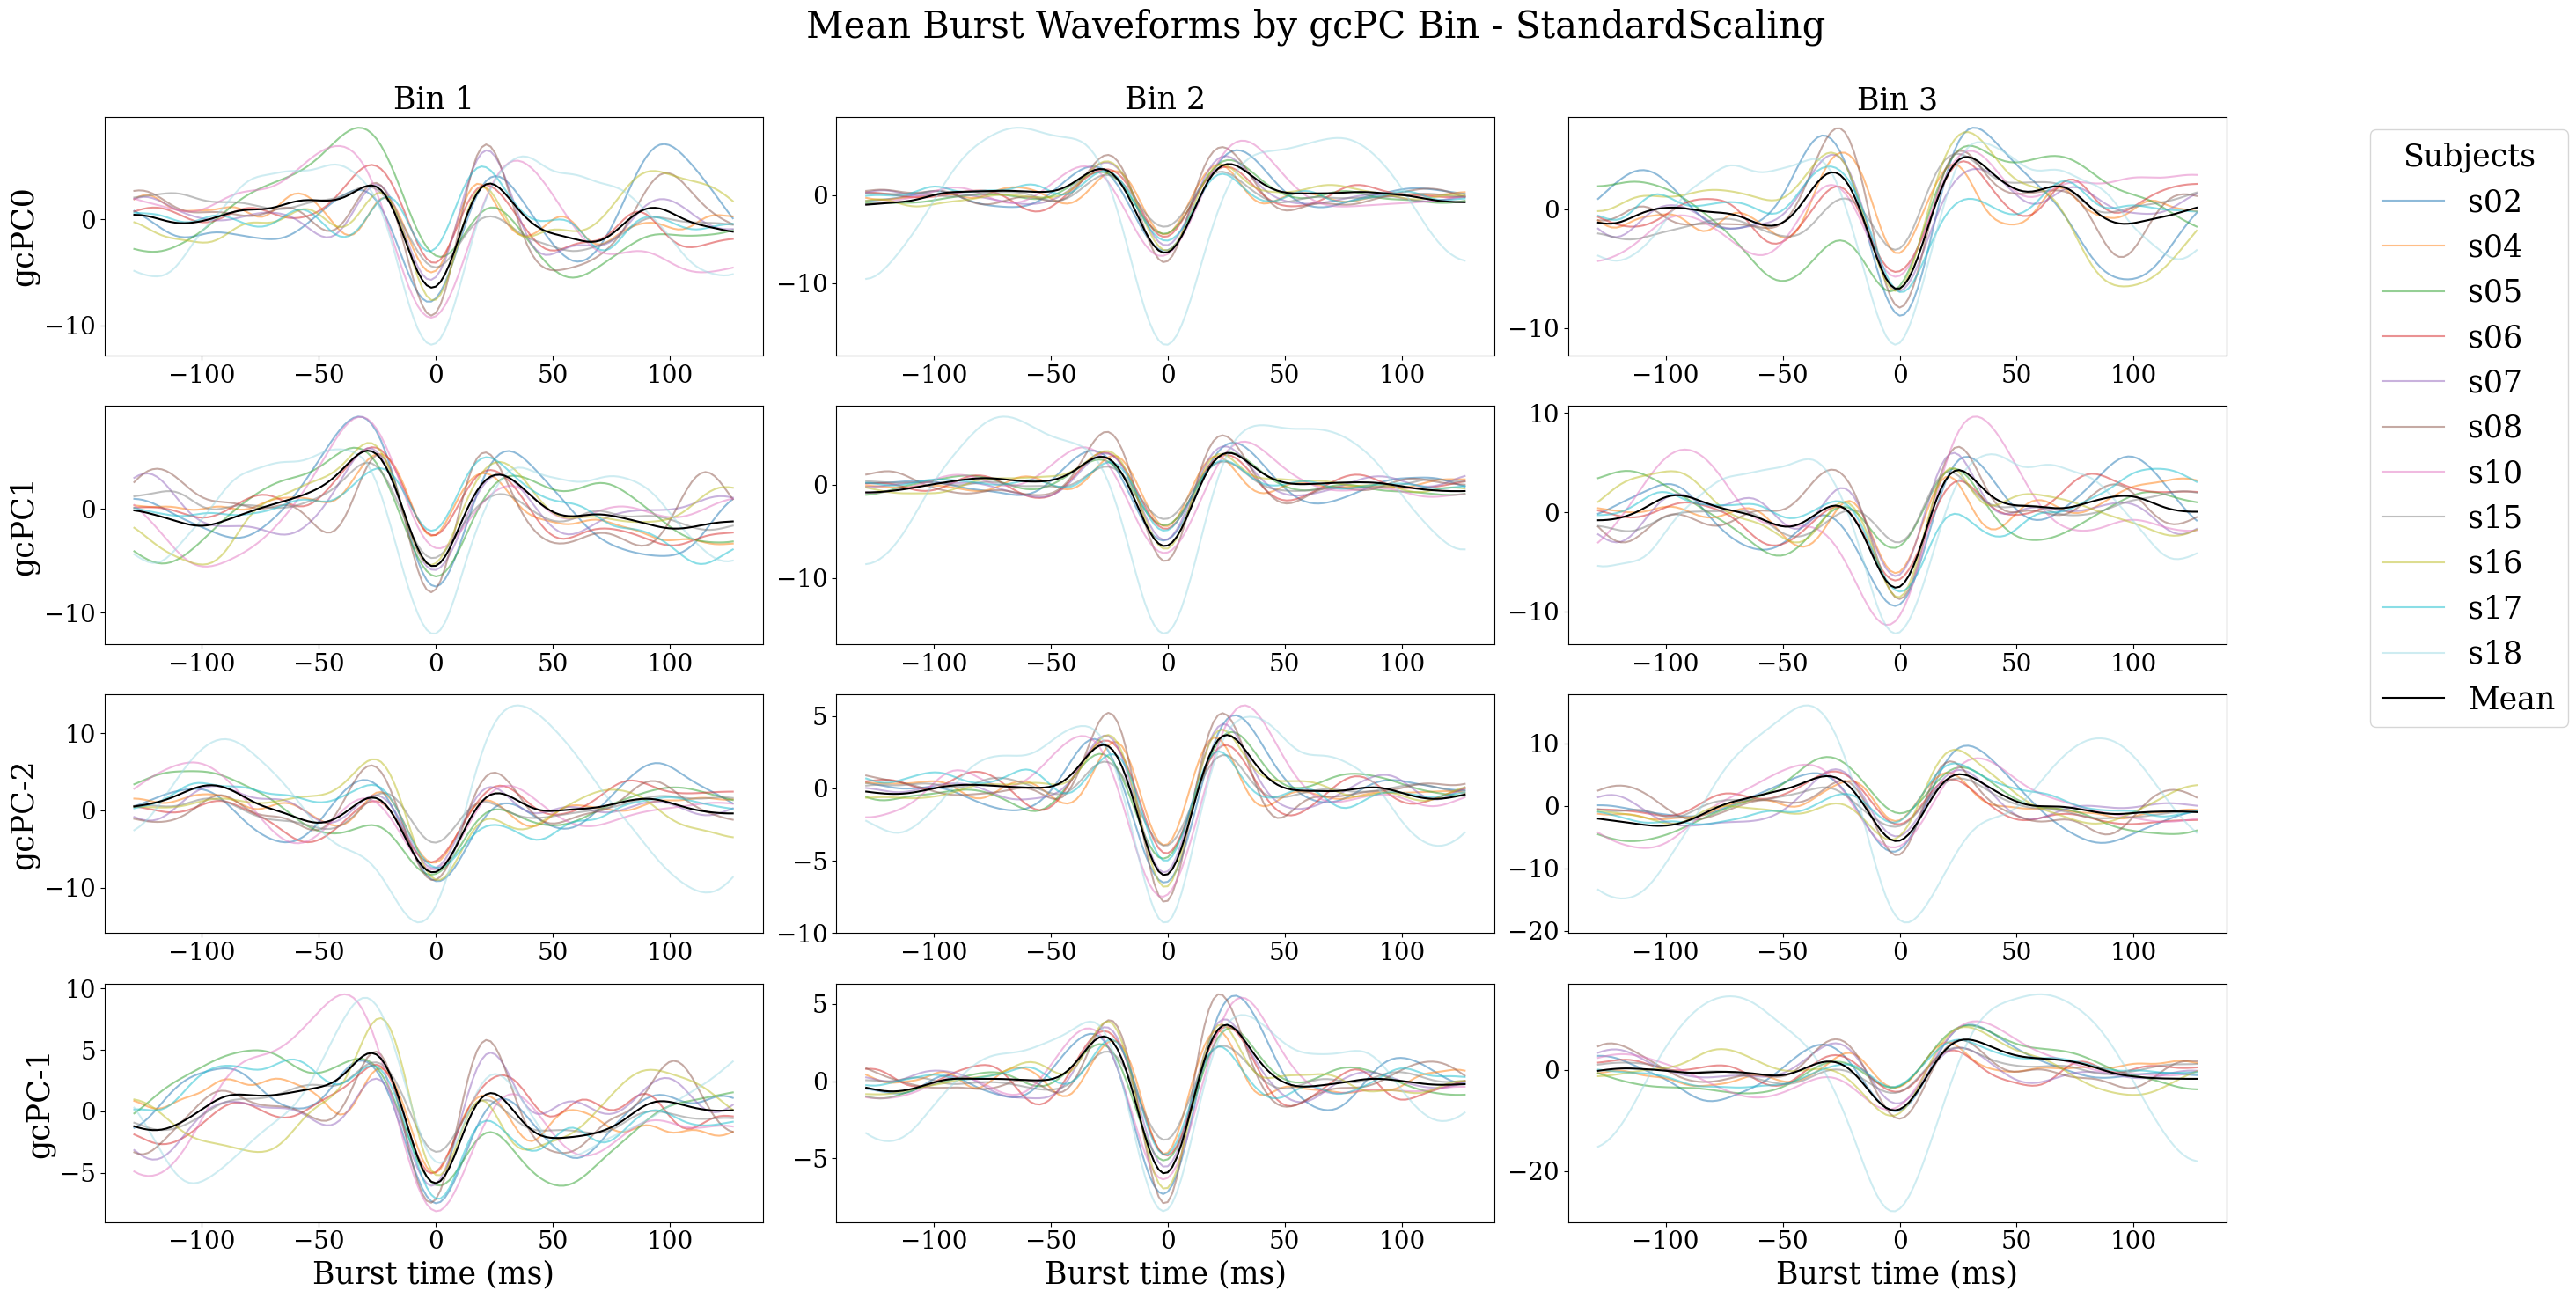

In [13]:
# Plot mean waveforms for each bin of each gcPC, averaged across subjects (excluding or not s18)

n_bins = 3

fig, ax = plt.subplots(len(cols), n_bins, figsize=(30, 15))

# Assign colors to subjects
cmap = plt.cm.get_cmap('tab20', len(subjects))
subject_colors = {sub: cmap(i) for i, sub in enumerate(subjects)}

labels = []
mean_waveforms = []  # for all subjects
for col in cols:
    bin_mean_waveforms = []  # reset for each col
    for bin in range(n_bins):
        sub_mean_waveforms = []  # for each bin
        for sub in subjects:  # [subjects != "s18"]
            sub_bursts_idx = np.isin(all_bursts['subject'], sub) & where
            pc_bin_lims = np.percentile(all_scores[sub_bursts_idx, col], np.linspace(0, 100, n_bins + 1))
            
            if bin == (n_bins - 1):
                lims = (all_scores[:, col] >= pc_bin_lims[bin])
            else:
                lims = (all_scores[:, col] >= pc_bin_lims[bin]) & (all_scores[:, col] < pc_bin_lims[bin + 1])
            
            idx = (all_bursts['subject'] == sub) & where & lims
            if np.sum(idx) > 0:  # check if there are bursts
                label = str(sub)
                if label not in labels:
                    labels.append(label)

                mean_sub_waveform = np.mean(all_bursts['waveform'][idx, :], axis=0)
                ax[col, bin].plot(burst_times, mean_sub_waveform, color=subject_colors[sub], label=label, alpha=0.5)
                ax[col, bin].tick_params(axis='both', which='major', labelsize=20)
                sub_mean_waveforms.append(mean_sub_waveform)
        
        if sub_mean_waveforms:
            label = "Mean"
            if label not in labels:
                labels.append(label)

            overall_mean = np.mean(np.array(sub_mean_waveforms), axis=0)
            ax[col, bin].plot(burst_times, overall_mean, label=label, color='black', alpha=1)
            bin_mean_waveforms.extend(sub_mean_waveforms)

        ax[0, bin].set_title(f'Bin {bin + 1}', fontsize=25)
        ax[len(cols)-1, bin].set_xlabel('Burst time (ms)', fontsize=25)

    if bin_mean_waveforms:
        mean_waveforms.append(np.mean(np.array(bin_mean_waveforms), axis=0))       

    ax[col, 0].set_ylabel(f'gcPC{col}', fontsize=25)

# Adjust subplots to make space for legend
fig.subplots_adjust(right=0.85)
fig.legend(labels=labels, bbox_to_anchor=(0.98, 0.90), title='Subjects', title_fontsize=25, fontsize=25)
fig.suptitle('Mean Burst Waveforms by gcPC Bin - StandardScaling', fontsize=30)
plt.tight_layout(rect=[0, 0, 0.85, 0.97])

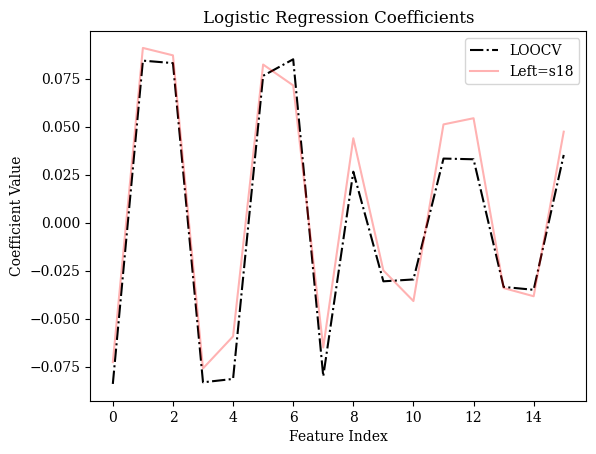

In [54]:
# Plot coefficients for each fold and for s18 
#(s18 being the test subject left out in the fold where it is the test subject,
# and included in the train set for every other fold)

for key, j in subjects_coefs.items():
    if key != 's18':
        mean_train_coefs = np.mean(subjects_coefs[key], axis=0)

plt.plot(mean_train_coefs[0],  linestyle='-.', color='black', label='LOOCV')  # linestyle='-', 
plt.plot(subjects_coefs['s18'][0].flatten(), color='red', alpha=0.3, label='Left=s18')
plt.legend()
plt.title('Logistic Regression Coefficients')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.show()

4


(Text(0, 0.5, 'Burst count'),
 Text(0.5, 0, 'Features'),
 Text(0.5, 1.0, 'Group-level - f(Features) = Burst Count'))

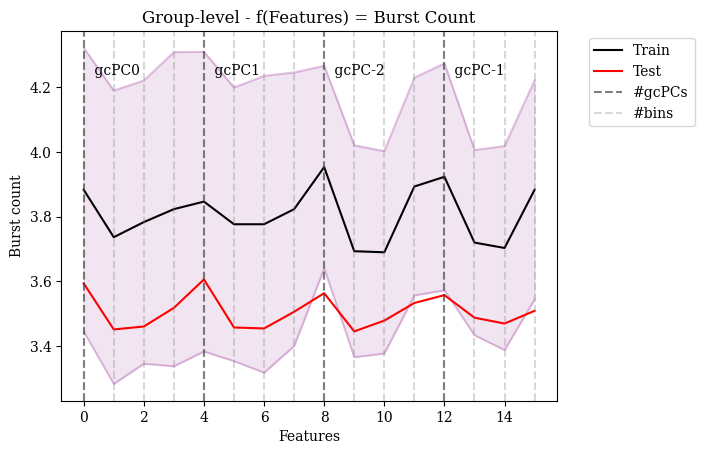

In [77]:
# Plot mean burst count as a function of features (gcPCs and percentiles) for Train vs Test (with SEM)

for key, j in subjects_bursts.items():
    if key != 's18':
        mean_train_bursts = np.mean(subjects_bursts[key], axis=0)
        std_train_bursts = np.std(subjects_bursts[key], axis=0)

upper = mean_train_bursts + np.sqrt(std_train_bursts)
lower = mean_train_bursts - np.sqrt(std_train_bursts)

y_lim = max(int(np.max(upper)), int(np.max(np.mean(subjects_bursts['s18'], axis=0))))
print(y_lim)

plt.plot(mean_train_bursts, color='black', label='Train')
plt.plot(upper, color='purple', alpha=0.2)
plt.plot(lower, color='purple', alpha=0.2)
plt.fill_between(range(len(mean_train_bursts)), lower, upper, color='purple', alpha=0.1)
plt.plot(np.mean(subjects_bursts['s18'], axis=0), color='red', label='Test')

for j, col in zip(range(0, len(np.mean(subjects_bursts['s18'], axis=0)), 4), cols):
    plt.axvline(j, color='black', linestyle='--', alpha=0.5, label="#gcPCs" if j == 0 else None)
    plt.text(j+0.2, y_lim+6*(y_lim/100), f" gcPC{col}")

for j in range(0, len(np.mean(subjects_bursts['s18'], axis=0))):
    plt.axvline(j, color='gray', linestyle='--', alpha=0.3, label="#bins" if j == 0 else None)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel("Burst count"), plt.xlabel("Features"), plt.title("Group-level - f(Features) = Burst Count")